# Stress Detection pada Mahasiswa
Deteksi tingkat stres mahasiswa berdasarkan pola aktivitas digital dan indikator psikologis.
Model dibangun menggunakan Multi-Layer Perceptron (MLP) dengan TensorFlow Functional API dan Keras.

---
## Step 1 - Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    mean_absolute_error
)
from sklearn.utils.class_weight import compute_class_weight

import keras
from keras import layers, regularizers, callbacks
import keras.ops as ops

SEED = 42
np.random.seed(SEED)

print("Keras version :", keras.__version__)


Keras version : 3.13.2


---
## Step 2 - Load Dataset

In [2]:
DATASET_PATH = "final_clean_dataset.csv"
DICT_PATH    = "data_dictionary.csv"

df        = pd.read_csv(DATASET_PATH)
data_dict = pd.read_csv(DICT_PATH)

CLASS_NAMES = ["Rendah", "Sedang", "Tinggi"]
PALETTE     = {0: "#4CAF50", 1: "#FF9800", 2: "#F44336"}

print("Shape dataset :", df.shape)
print()
print("Distribusi target:")
vc = df["stress_level"].value_counts().sort_index()
for k, v in vc.items():
    print("  Kelas", k, "(" + CLASS_NAMES[k] + ") :", v, "sampel")
df.head()


Shape dataset : (1000, 24)

Distribusi target:
  Kelas 0 (Rendah) : 338 sampel
  Kelas 1 (Sedang) : 331 sampel
  Kelas 2 (Tinggi) : 331 sampel


,anxiety_level,self_esteem,mental_health_history,depression,headache,sleep_quality,academic_performance,study_load,future_career_concerns,social_support,...,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,digital_overload_score,productivity_balance_score,study_stress_ratio,mental_risk_score
0,14,20,0,11,2,2,3,2,3,2,...,2.61,7.15,24,4.43,0.55,2.40,13.98,0.152355,0.666667,30
1,15,8,1,15,5,1,1,4,5,1,...,2.13,13.79,18,4.67,4.42,2.43,20.89,1.412141,2.000000,39
2,12,18,1,14,2,2,2,3,2,2,...,7.28,4.50,11,4.58,1.71,2.83,11.91,0.206522,1.000000,31
3,16,12,1,15,4,1,2,4,4,1,...,1.20,6.29,21,3.18,3.42,4.58,14.05,1.554545,2.000000,40
4,16,28,0,7,2,5,4,3,2,1,...,6.31,12.59,14,3.15,0.13,4.00,19.74,0.017784,0.500000,33


---
## Step 3 - Data Dictionary

In [3]:
data_dict.style.set_properties(**{"text-align": "left"}).hide(axis="index")


column_name,description,data_type,role
anxiety_level,Tingkat kecemasan mahasiswa.,int64,feature
self_esteem,Tingkat kepercayaan diri mahasiswa.,int64,feature
mental_health_history,Riwayat kesehatan mental.,int64,feature
depression,Tingkat depresi mahasiswa.,int64,feature
headache,Intensitas sakit kepala.,int64,feature
sleep_quality,Kualitas tidur mahasiswa.,int64,feature
academic_performance,Performa akademik mahasiswa.,int64,feature
study_load,Beban belajar mahasiswa.,int64,feature
future_career_concerns,Kekhawatiran terhadap karier masa depan.,int64,feature
social_support,Dukungan sosial yang diterima mahasiswa.,int64,feature


---
## Step 4 - Validasi Dataset

In [4]:
print("=== Cek Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values.")
print()

print("=== Cek Duplikat ===")
n_dup = df.duplicated().sum()
print("Jumlah duplikat :", n_dup)
print()

print("=== Cek Tipe Data ===")
print(df.dtypes)
print()

print("=== Cek Nilai Negatif pada Fitur Non-Negatif ===")
non_neg_cols = [
    "Total_App_Usage_Hours", "Daily_Screen_Time_Hours",
    "Social_Media_Usage_Hours", "Productivity_App_Usage_Hours",
    "Gaming_App_Usage_Hours", "digital_overload_score",
    "productivity_balance_score", "study_stress_ratio"
]
all_clean = True
for col in non_neg_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print("  " + col + ":", n_neg, "nilai negatif")
        all_clean = False
if all_clean:
    print("Tidak ada nilai negatif.")
print()

print("=== Cek Range Nilai Fitur Ordinal ===")
ordinal_ranges = {
    "anxiety_level"          : (0, 21),
    "self_esteem"            : (0, 30),
    "depression"             : (0, 27),
    "headache"               : (0, 5),
    "sleep_quality"          : (0, 5),
    "academic_performance"   : (0, 5),
    "study_load"             : (0, 5),
    "future_career_concerns" : (0, 5),
    "social_support"         : (0, 3),
    "peer_pressure"          : (0, 5),
    "bullying"               : (0, 5),
    "mental_health_history"  : (0, 1),
    "stress_level"           : (0, 2),
}
all_ok = True
for col, (lo, hi) in ordinal_ranges.items():
    out = df[(df[col] < lo) | (df[col] > hi)]
    if len(out) > 0:
        print("  " + col + ":", len(out), "nilai di luar range [" + str(lo) + ", " + str(hi) + "]")
        all_ok = False
if all_ok:
    print("Semua fitur ordinal dalam range yang valid.")
print()

print("=== Ringkasan Validasi ===")
print("Missing values  :", df.isnull().sum().sum())
print("Duplikat        :", df.duplicated().sum())
print("Shape akhir     :", df.shape)
print("Dataset siap digunakan.")


=== Cek Missing Values ===
Tidak ada missing values.

=== Cek Duplikat ===
Jumlah duplikat : 0

=== Cek Tipe Data ===
anxiety_level                     int64
self_esteem                       int64
mental_health_history             int64
depression                        int64
headache                          int64
sleep_quality                     int64
academic_performance              int64
study_load                        int64
future_career_concerns            int64
social_support                    int64
peer_pressure                     int64
bullying                          int64
stress_level                      int64
Age                               int64
Total_App_Usage_Hours           float64
Daily_Screen_Time_Hours         float64
Number_of_Apps_Used               int64
Social_Media_Usage_Hours        float64
Productivity_App_Usage_Hours    float64
Gaming_App_Usage_Hours          float64
digital_overload_score          float64
productivity_balance_score      float64
st

---
## Step 5 - Exploratory Data Analysis

In [5]:
df.describe().round(2).T.style.background_gradient(cmap="Blues")


,count,mean,std,min,25%,50%,75%,max
anxiety_level,1000.000000,11.060000,6.080000,0.000000,6.000000,11.000000,16.000000,21.000000
self_esteem,1000.000000,17.870000,8.940000,0.000000,11.000000,19.000000,26.000000,30.000000
mental_health_history,1000.000000,0.490000,0.500000,0.000000,0.000000,0.000000,1.000000,1.000000
depression,1000.000000,12.510000,7.680000,0.000000,7.000000,12.000000,19.000000,27.000000
headache,1000.000000,2.500000,1.400000,0.000000,1.000000,3.000000,3.000000,5.000000
sleep_quality,1000.000000,2.670000,1.540000,0.000000,1.000000,3.000000,4.000000,5.000000
academic_performance,1000.000000,2.780000,1.400000,0.000000,2.000000,2.000000,4.000000,5.000000
study_load,1000.000000,2.630000,1.310000,0.000000,2.000000,2.000000,3.000000,5.000000
future_career_concerns,1000.000000,2.650000,1.530000,0.000000,1.000000,2.000000,4.000000,5.000000
social_support,1000.000000,1.900000,1.040000,0.000000,1.000000,2.000000,3.000000,3.000000


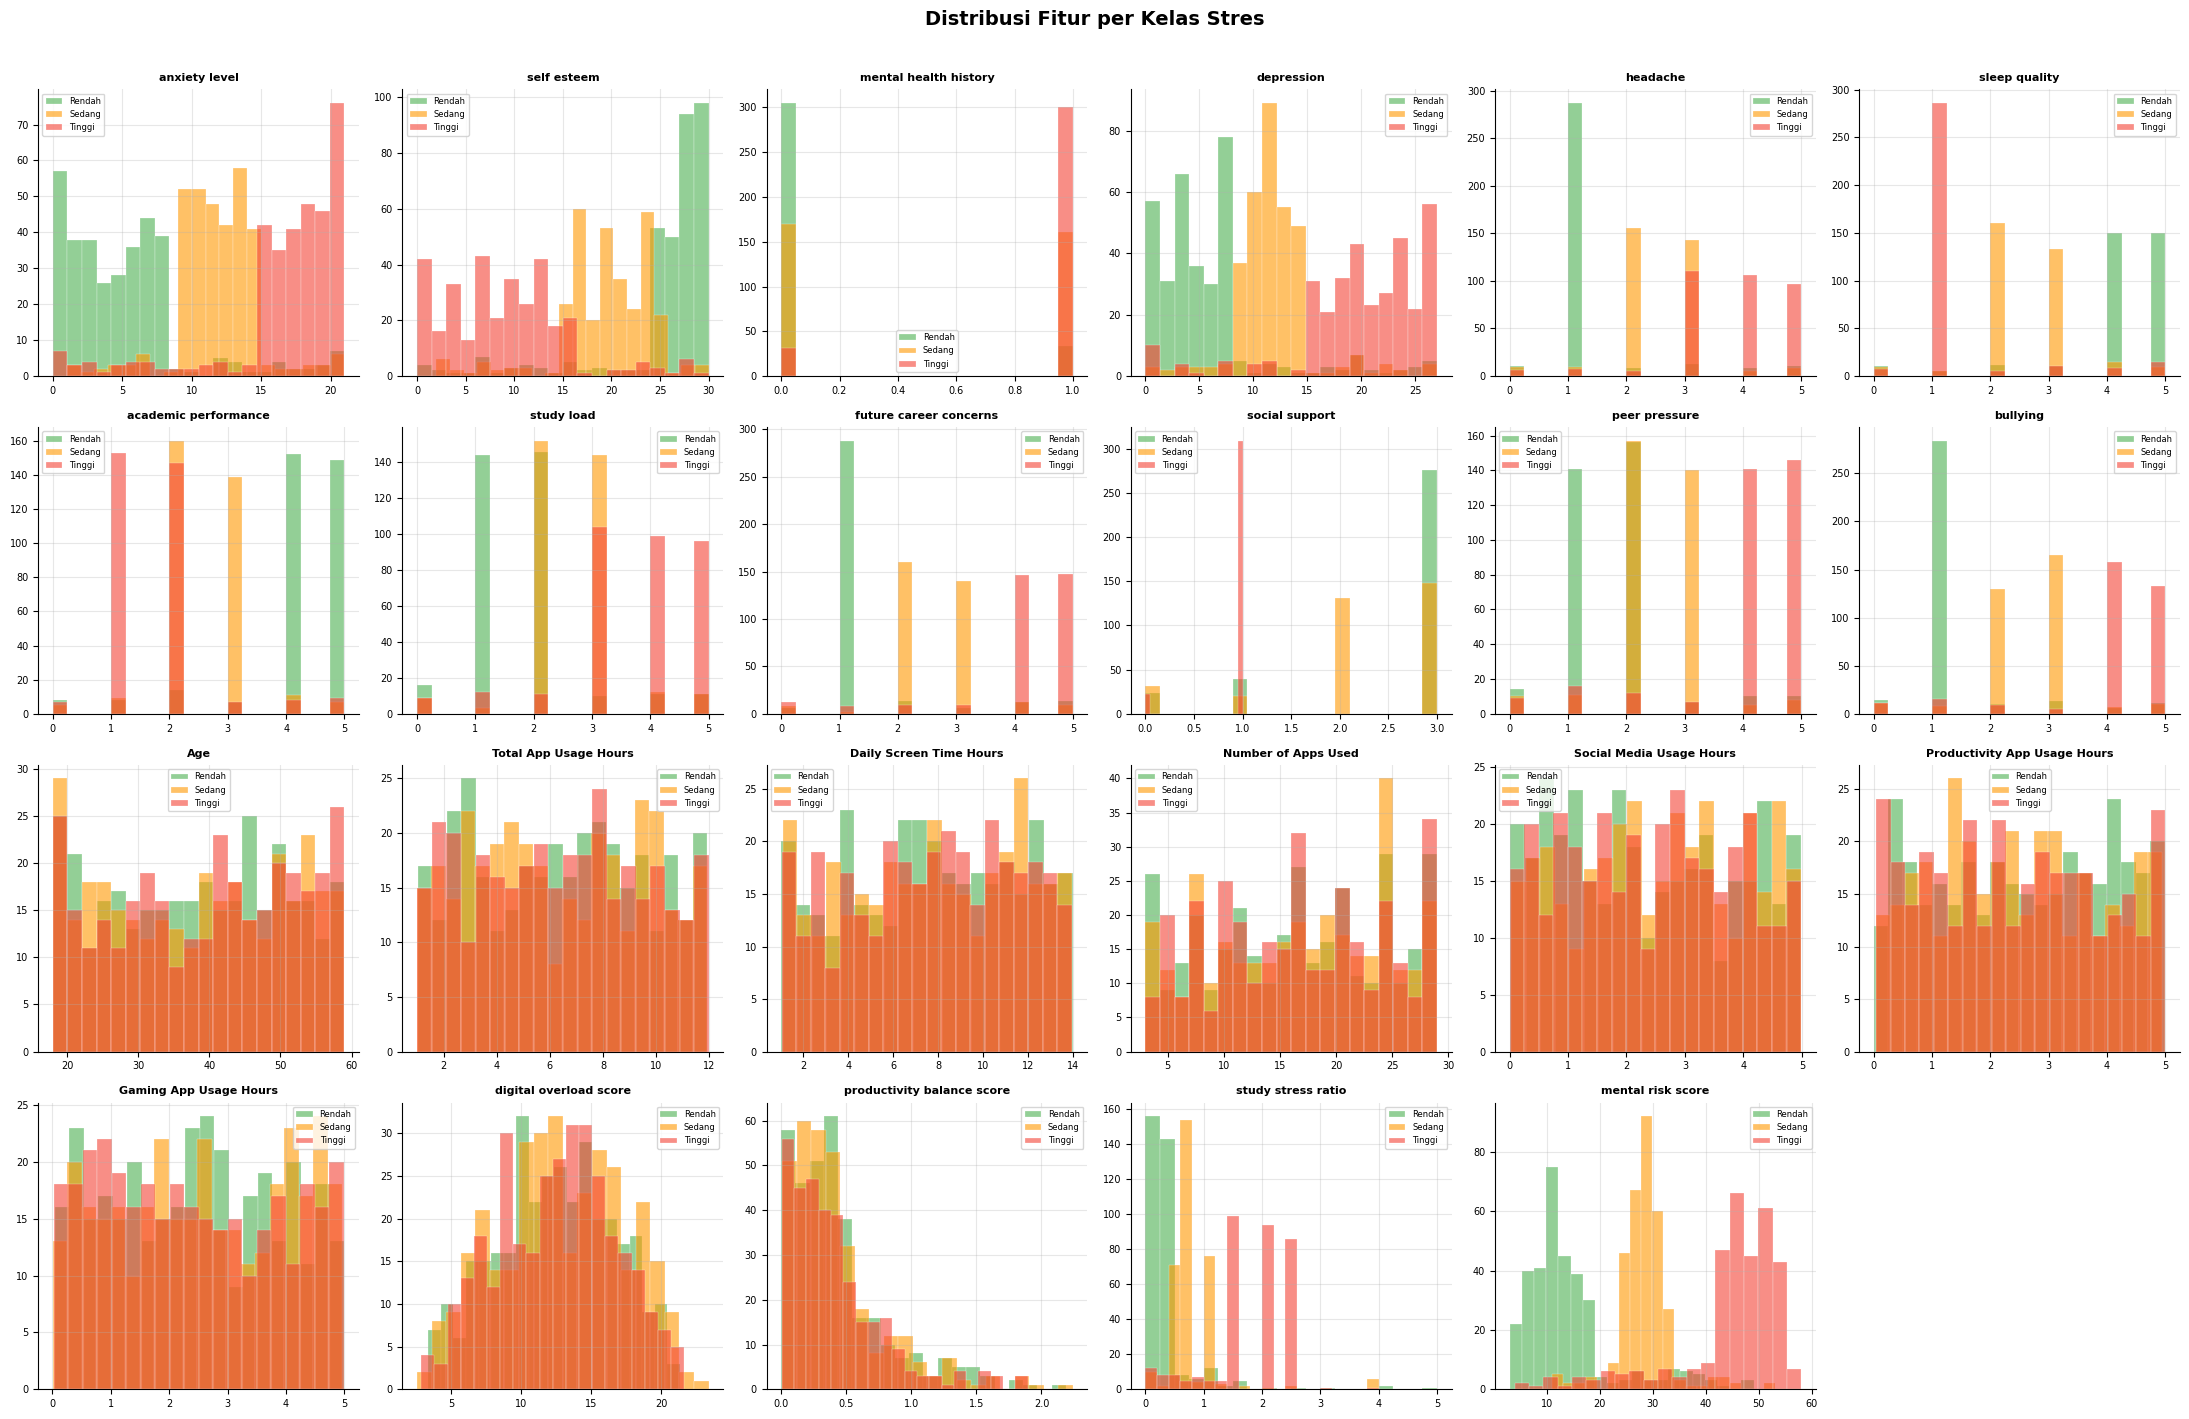

In [6]:
FEATURE_COLS_RAW = [c for c in df.columns if c != "stress_level"]

fig, axes = plt.subplots(4, 6, figsize=(22, 14))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS_RAW):
    ax = axes[i]
    for cls in [0, 1, 2]:
        data = df[df["stress_level"] == cls][feat]
        ax.hist(data, bins=20, alpha=0.6, color=PALETTE[cls],
                label=CLASS_NAMES[cls], edgecolor="white", linewidth=0.3)
    ax.set_title(feat.replace("_", " "), fontsize=8, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)
    sns.despine(ax=ax)

for j in range(len(FEATURE_COLS_RAW), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribusi Fitur per Kelas Stres", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


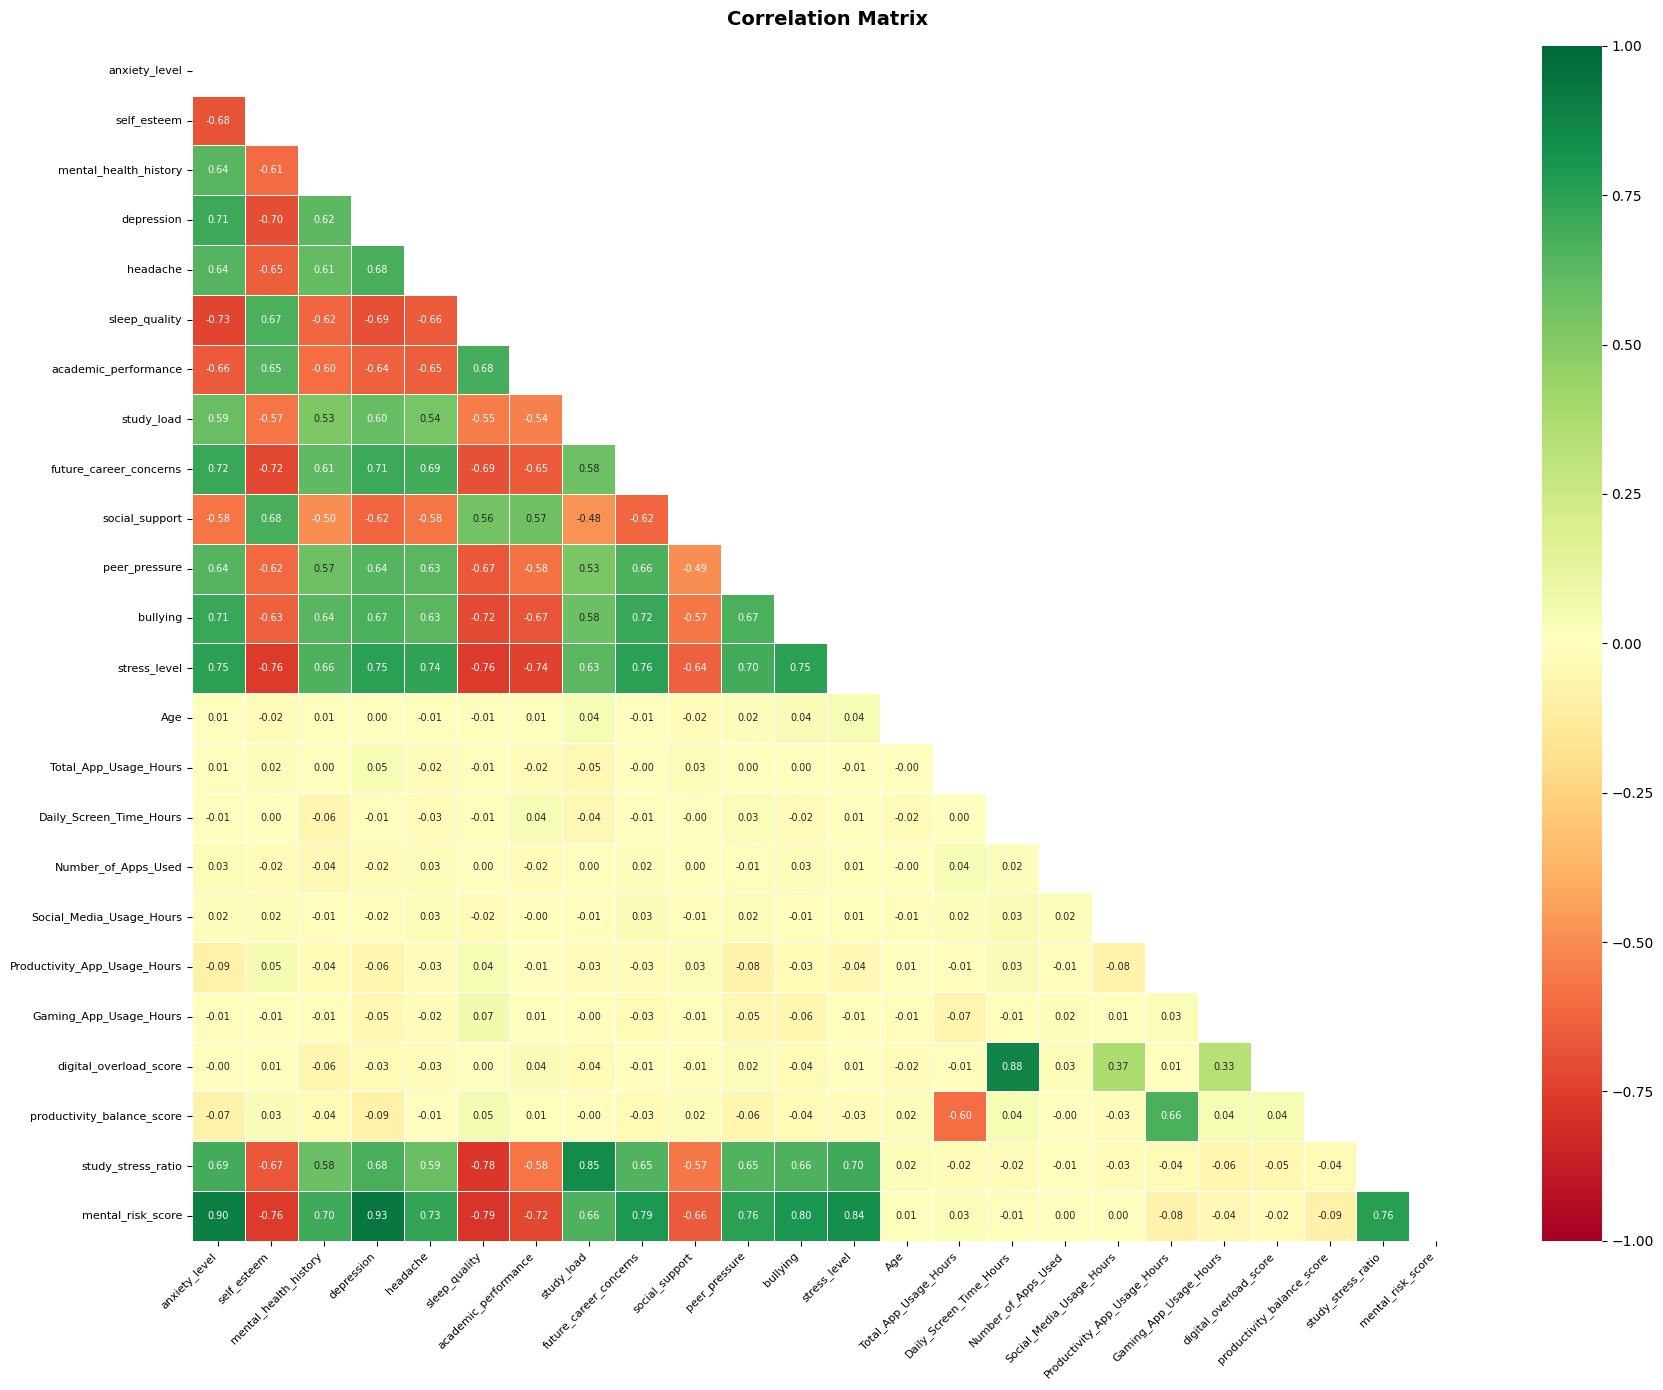

In [7]:
plt.figure(figsize=(18, 14))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.4, annot_kws={"size": 7})
plt.title("Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


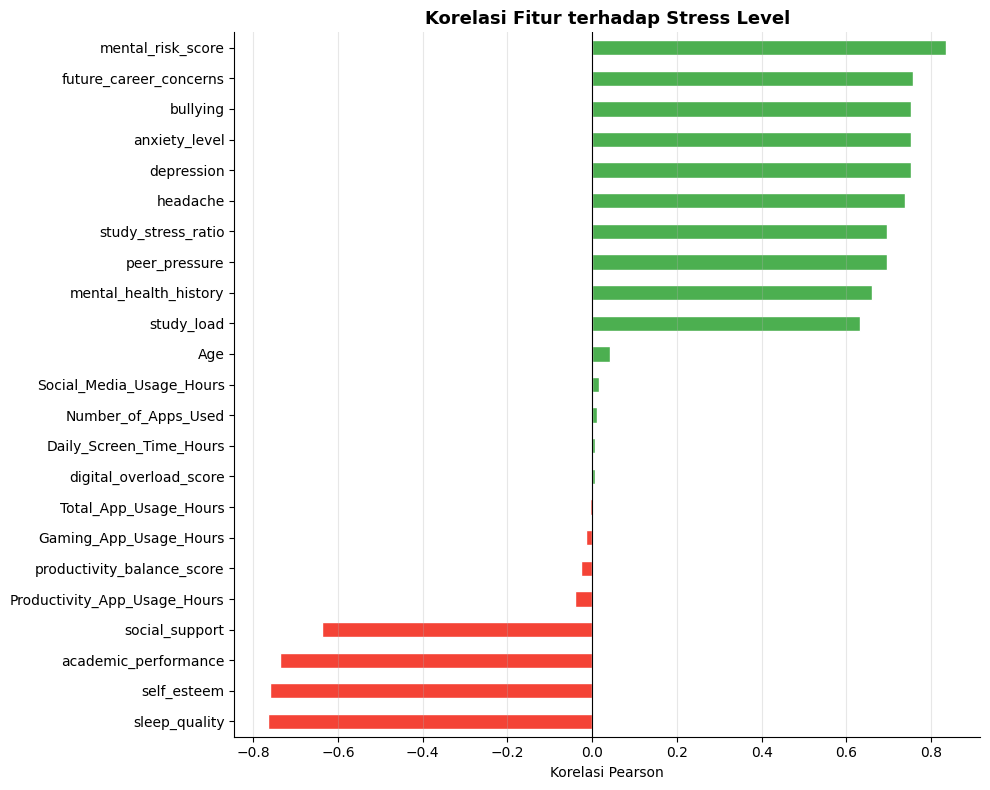

In [8]:
corr_target = df.corr()["stress_level"].drop("stress_level").sort_values()
bar_colors  = ["#F44336" if v < 0 else "#4CAF50" for v in corr_target]

plt.figure(figsize=(10, 8))
corr_target.plot(kind="barh", color=bar_colors, edgecolor="white", ax=plt.gca())
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Korelasi Fitur terhadap Stress Level", fontsize=13, fontweight="bold")
plt.xlabel("Korelasi Pearson")
plt.grid(True, alpha=0.3, axis="x")
sns.despine()
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 6 - Feature Engineering

In [9]:
df_fe = df.copy()

df_fe["screen_to_sleep_ratio"]    = df_fe["Daily_Screen_Time_Hours"] / (df_fe["sleep_quality"] + 1)
df_fe["social_vs_productivity"]   = df_fe["Social_Media_Usage_Hours"] / (df_fe["Productivity_App_Usage_Hours"] + 0.01)
df_fe["mental_digital_composite"] = df_fe["mental_risk_score"] * df_fe["digital_overload_score"]
df_fe["anxiety_depression_sum"]   = df_fe["anxiety_level"] + df_fe["depression"]
df_fe["support_pressure_diff"]    = df_fe["social_support"] - df_fe["peer_pressure"]
df_fe["passive_screen_ratio"]     = (
    df_fe["Social_Media_Usage_Hours"] + df_fe["Gaming_App_Usage_Hours"]
) / (df_fe["Total_App_Usage_Hours"] + 0.01)
df_fe["academic_stress_index"]    = df_fe["study_load"] * df_fe["future_career_concerns"]
df_fe["wellbeing_deficit"]        = (
    df_fe["anxiety_level"] + df_fe["depression"] + df_fe["peer_pressure"]
) - (df_fe["social_support"] * 2 + df_fe["sleep_quality"])

new_features = [
    "screen_to_sleep_ratio",
    "social_vs_productivity",
    "mental_digital_composite",
    "anxiety_depression_sum",
    "support_pressure_diff",
    "passive_screen_ratio",
    "academic_stress_index",
    "wellbeing_deficit",
]

print("Fitur baru ditambahkan :", len(new_features))
print("Total fitur sekarang   :", df_fe.shape[1] - 1)
df_fe[new_features + ["stress_level"]].describe().round(3)


Fitur baru ditambahkan : 8
Total fitur sekarang   : 31


,screen_to_sleep_ratio,social_vs_productivity,mental_digital_composite,anxiety_depression_sum,support_pressure_diff,passive_screen_ratio,academic_stress_index,wellbeing_deficit,stress_level
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,2.592,2.682,363.629,23.567,-0.822,1.133,8.124,19.813,0.993
std,1.961,6.838,228.560,12.736,2.143,1.077,7.346,16.439,0.818
min,0.168,0.000,18.510,0.000,-5.000,0.009,0.000,-9.000,0.000
25%,1.203,0.489,173.442,12.000,-3.000,0.479,2.000,4.000,0.000
50%,2.071,0.981,326.280,23.000,0.000,0.771,6.000,18.000,1.000
75%,3.431,2.082,504.460,35.000,1.000,1.372,15.000,36.000,2.000
max,13.950,93.800,1190.200,48.000,2.000,7.233,25.000,50.000,2.000


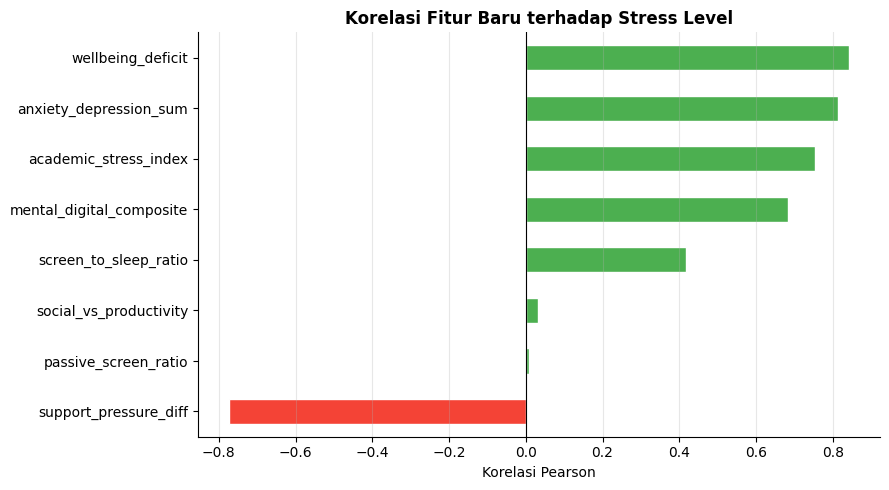

In [10]:
corr_new   = df_fe[new_features + ["stress_level"]].corr()["stress_level"].drop("stress_level").sort_values()
bar_colors = ["#F44336" if v < 0 else "#4CAF50" for v in corr_new]

plt.figure(figsize=(9, 5))
corr_new.plot(kind="barh", color=bar_colors, edgecolor="white", ax=plt.gca())
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Korelasi Fitur Baru terhadap Stress Level", fontsize=12, fontweight="bold")
plt.xlabel("Korelasi Pearson")
plt.grid(True, alpha=0.3, axis="x")
sns.despine()
plt.tight_layout()
plt.savefig("new_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 7 - Preprocessing Data

In [11]:
FEATURE_COLS = [c for c in df_fe.columns if c != "stress_level"]

X = df_fe[FEATURE_COLS].values.astype(np.float32)
y = df_fe["stress_level"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

class_weights_arr = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Train  :", X_train_sc.shape[0], "samples")
print("Val    :", X_val_sc.shape[0],   "samples")
print("Test   :", X_test_sc.shape[0],  "samples")
print("Fitur  :", X_train_sc.shape[1])
print()
print("Class weights:", {k: round(v, 4) for k, v in class_weight_dict.items()})


Train  : 700 samples
Val    : 150 samples
Test   : 150 samples
Fitur  : 31

Class weights: {0: np.float64(0.9887), 1: np.float64(1.0057), 2: np.float64(1.0057)}


---
## Step 8 - Custom Layers

In [12]:
@keras.saving.register_keras_serializable(package="StressDetection")
class GaussianNoiseLayer(layers.Layer):
    def __init__(self, stddev=0.05, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        if training:
            noise = keras.random.normal(shape=ops.shape(inputs), stddev=self.stddev)
            return inputs + noise
        return inputs

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"stddev": self.stddev})
        return cfg


@keras.saving.register_keras_serializable(package="StressDetection")
class FeatureNormalizationLayer(layers.Layer):
    def build(self, input_shape):
        n = input_shape[-1]
        self.gamma = self.add_weight(
            name="gamma", shape=(n,), initializer="ones", trainable=True
        )
        self.beta = self.add_weight(
            name="beta", shape=(n,), initializer="zeros", trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        mean   = ops.mean(inputs, axis=-1, keepdims=True)
        std    = ops.std(inputs, axis=-1, keepdims=True) + 1e-6
        normed = (inputs - mean) / std
        return normed * self.gamma + self.beta

    def get_config(self):
        return super().get_config()


print("Custom layers siap.")


Custom layers siap.


---
## Step 9 - Custom Loss Function

In [13]:
custom_loss = keras.losses.CategoricalCrossentropy(
    label_smoothing=0.02,
    name="categorical_crossentropy_smoothed"
)
print("Loss function siap: CategoricalCrossentropy dengan label_smoothing=0.02")


Loss function siap: CategoricalCrossentropy dengan label_smoothing=0.05


---
## Step 10 - Custom Callbacks

In [14]:
class StressMonitorCallback(callbacks.Callback):
    def __init__(self, target_accuracy=0.92, print_every=10):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.print_every     = print_every
        self.best_val_acc    = 0.0
        self.best_epoch      = 0

    def on_epoch_end(self, epoch, logs=None):
        logs     = logs or {}
        tr_acc   = logs.get("accuracy", 0)
        val_acc  = logs.get("val_accuracy", 0)
        tr_loss  = logs.get("loss", 0)
        val_loss = logs.get("val_loss", 0)
        lr       = float(self.model.optimizer.learning_rate)

        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.best_epoch   = epoch + 1

        if val_acc >= self.target_accuracy:
            print()
            print("Target accuracy {:.0f}% tercapai pada Epoch {}. Training dihentikan.".format(
                self.target_accuracy * 100, epoch + 1))
            self.model.stop_training = True
            return

        if (epoch + 1) % self.print_every == 0 or epoch == 0:
            gap    = tr_acc - val_acc
            status = "[OVERFIT]" if gap > 0.08 else "[OK]"
            print("Epoch {:3d} | loss={:.4f} val_loss={:.4f} | acc={:.4f} val_acc={:.4f} | lr={:.2e} | {}".format(
                epoch + 1, tr_loss, val_loss, tr_acc, val_acc, lr, status))

    def on_train_end(self, logs=None):
        print()
        print("Best val_accuracy: {:.4f} pada Epoch {}".format(
            self.best_val_acc, self.best_epoch))


class WarmupCosineScheduler(callbacks.Callback):
    def __init__(self, initial_lr=1e-5, max_lr=1e-3, warmup_epochs=20, total_epochs=300):
        super().__init__()
        self.initial_lr    = initial_lr
        self.max_lr        = max_lr
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.initial_lr + (self.max_lr - self.initial_lr) * (epoch / self.warmup_epochs)
        else:
            progress = (epoch - self.warmup_epochs) / max(self.total_epochs - self.warmup_epochs, 1)
            lr = self.initial_lr + 0.5 * (self.max_lr - self.initial_lr) * (1 + np.cos(np.pi * progress))
        self.model.optimizer.learning_rate.assign(float(lr))


print("Custom callbacks siap.")


Custom callbacks siap.


---
## Step 11 - Arsitektur MLP (Functional API)

In [15]:
def build_mlp(input_dim, n_classes=3, dropout_rate=0.30, l2_lambda=5e-5):
    reg = regularizers.l2(l2_lambda)
    inp = keras.Input(shape=(input_dim,), name="input")

    x  = FeatureNormalizationLayer(name="feature_norm")(inp)
    x  = GaussianNoiseLayer(stddev=0.05, name="gaussian_noise")(x)

    x  = layers.Dense(256, kernel_regularizer=reg, name="dense_1")(x)
    x  = layers.BatchNormalization(name="bn_1")(x)
    x  = layers.Activation("swish", name="act_1")(x)
    x  = layers.Dropout(dropout_rate, name="drop_1")(x)

    x2 = layers.Dense(256, kernel_regularizer=reg, name="dense_2")(x)
    x2 = layers.BatchNormalization(name="bn_2")(x2)
    x2 = layers.Activation("swish", name="act_2")(x2)
    x2 = layers.Dropout(dropout_rate, name="drop_2")(x2)
    x  = layers.Add(name="skip_1")([x, x2])

    x  = layers.Dense(128, kernel_regularizer=reg, name="dense_3")(x)
    x  = layers.BatchNormalization(name="bn_3")(x)
    x  = layers.Activation("swish", name="act_3")(x)
    x  = layers.Dropout(dropout_rate * 0.8, name="drop_3")(x)

    x  = layers.Dense(64, kernel_regularizer=reg, name="dense_4")(x)
    x  = layers.BatchNormalization(name="bn_4")(x)
    x  = layers.Activation("swish", name="act_4")(x)
    x  = layers.Dropout(dropout_rate * 0.65, name="drop_4")(x)

    out = layers.Dense(n_classes, activation="softmax", name="output")(x)
    return keras.Model(inputs=inp, outputs=out, name="StressMLP")


print("Arsitektur MLP siap (256-256-128-64).")


Arsitektur MLP siap (256-256-128-64).


---
## Step 12 - Kompilasi dan Training

In [16]:
from sklearn.model_selection import StratifiedKFold
from keras.utils import to_categorical

CUSTOM_OBJ = {
    "GaussianNoiseLayer"        : GaussianNoiseLayer,
    "FeatureNormalizationLayer" : FeatureNormalizationLayer,
}

N_FOLDS = 10
EPOCHS  = 300
BATCH   = 32

ensemble_models  = []
ensemble_history = []

X_combined = np.concatenate([X_train_sc, X_val_sc], axis=0)
y_combined = np.concatenate([y_train, y_val], axis=0)

print("Data gabungan (train+val) :", X_combined.shape[0], "sampel")
print("Test data                 :", X_test_sc.shape[0],  "sampel")
print("Jumlah fold / model       :", N_FOLDS)
print()

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_combined, y_combined)):
    X_fold_train = X_combined[train_idx]
    y_fold_train = to_categorical(y_combined[train_idx], num_classes=3)
    X_fold_val   = X_combined[val_idx]
    y_fold_val   = to_categorical(y_combined[val_idx], num_classes=3)

    fold_seed = 42 + fold_idx * 7
    np.random.seed(fold_seed)
    keras.utils.set_random_seed(fold_seed)

    m = build_mlp(input_dim=X_combined.shape[1], n_classes=3)
    m.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss=custom_loss,
        metrics=["accuracy"]
    )

    ckpt_path = "ensemble_model_{}.keras".format(fold_idx)
    cb_list = [
        StressMonitorCallback(target_accuracy=0.95, print_every=50),
        WarmupCosineScheduler(initial_lr=1e-5, max_lr=1e-3,
                              warmup_epochs=20, total_epochs=EPOCHS),
        callbacks.EarlyStopping(
            monitor="val_accuracy", patience=40,
            restore_best_weights=True, mode="max"
        ),
        callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_accuracy",
            save_best_only=True, mode="max", verbose=0
        )
    ]

    print("Training model {}/{} (fold={}, seed={}, train={}, val={})...".format(
        fold_idx + 1, N_FOLDS, fold_idx + 1, fold_seed,
        len(train_idx), len(val_idx)))

    hist = m.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=cb_list,
        verbose=0
    )

    best_val = max(hist.history["val_accuracy"])
    print("  Best val_accuracy: {:.4f} ({:.2f}%)".format(best_val, best_val * 100))
    print()

    ensemble_models.append(keras.models.load_model(ckpt_path, custom_objects=CUSTOM_OBJ))
    ensemble_history.append(hist.history)

print("Semua {} model ensemble selesai dilatih.".format(N_FOLDS))


Data gabungan (train+val) : 850 sampel
Test data                 : 150 sampel
Jumlah fold / model       : 10

Training model 1/10 (fold=1, seed=42, train=765, val=85)...
Epoch   1 | loss=1.1701 val_loss=1.0506 | acc=0.4706 val_acc=0.5529 | lr=1.00e-05 | [OK]
Epoch  50 | loss=0.2552 val_loss=0.4968 | acc=0.9908 val_acc=0.9059 | lr=9.74e-04 | [OVERFIT]

Best val_accuracy: 0.9176 pada Epoch 12
  Best val_accuracy: 0.9176 (91.76%)

Training model 2/10 (fold=2, seed=49, train=765, val=85)...
Epoch   1 | loss=1.3314 val_loss=1.1391 | acc=0.3490 val_acc=0.3294 | lr=1.00e-05 | [OK]
Epoch  50 | loss=0.2638 val_loss=0.4517 | acc=0.9895 val_acc=0.9059 | lr=9.74e-04 | [OVERFIT]

Best val_accuracy: 0.9176 pada Epoch 14
  Best val_accuracy: 0.9176 (91.76%)

Training model 3/10 (fold=3, seed=56, train=765, val=85)...
Epoch   1 | loss=1.6681 val_loss=1.1923 | acc=0.2105 val_acc=0.2353 | lr=1.00e-05 | [OK]
Epoch  50 | loss=0.2639 val_loss=0.5601 | acc=0.9869 val_acc=0.8471 | lr=9.74e-04 | [OVERFIT]

Be

---
## Step 13 - Visualisasi Hasil Training

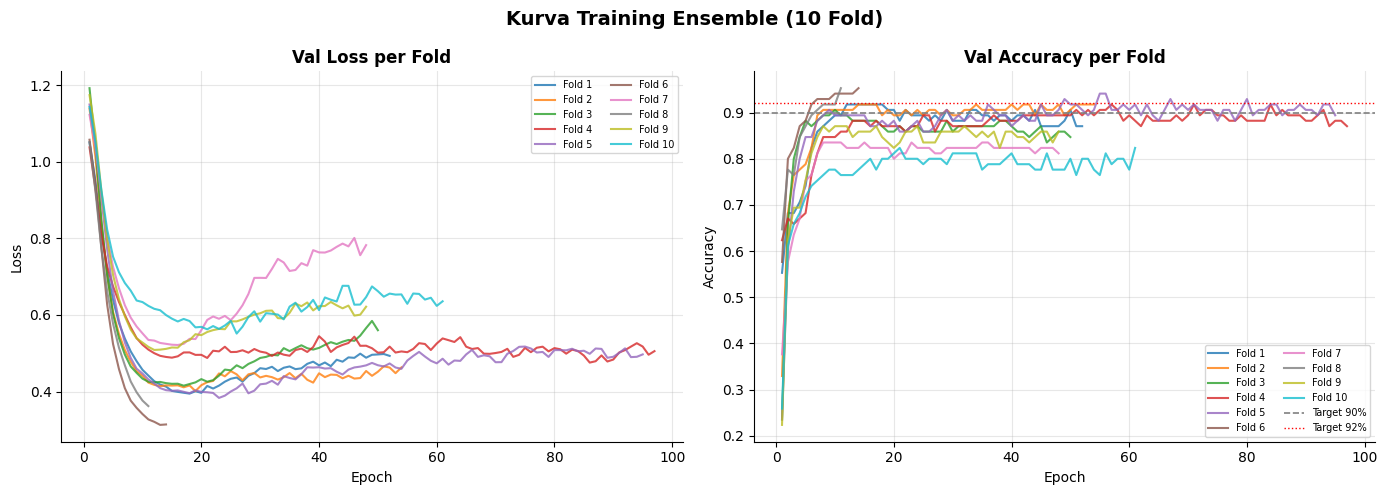

Val accuracy per fold:
  Fold  1 : 0.9176 (91.76%)
  Fold  2 : 0.9176 (91.76%)
  Fold  3 : 0.9059 (90.59%)
  Fold  4 : 0.9176 (91.76%)
  Fold  5 : 0.9412 (94.12%)
  Fold  6 : 0.9529 (95.29%)
  Fold  7 : 0.8353 (83.53%)
  Fold  8 : 0.9529 (95.29%)
  Fold  9 : 0.8706 (87.06%)
  Fold 10 : 0.8235 (82.35%)
  Rata-rata: 0.9035 (90.35%)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.tab10

for i, hist_i in enumerate(ensemble_history):
    color      = cmap(i / len(ensemble_history))
    epochs_ran = range(1, len(hist_i["loss"]) + 1)
    axes[0].plot(epochs_ran, hist_i["val_loss"],
                 color=color, lw=1.5, alpha=0.8, label="Fold {}".format(i + 1))
    axes[1].plot(epochs_ran, hist_i["val_accuracy"],
                 color=color, lw=1.5, alpha=0.8, label="Fold {}".format(i + 1))

axes[0].set_title("Val Loss per Fold", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)
sns.despine(ax=axes[0])

axes[1].axhline(0.90, color="gray", lw=1.2, linestyle="--", label="Target 90%")
axes[1].axhline(0.92, color="red",  lw=1.0, linestyle=":",  label="Target 92%")
axes[1].set_title("Val Accuracy per Fold", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)
sns.despine(ax=axes[1])

plt.suptitle("Kurva Training Ensemble ({} Fold)".format(len(ensemble_history)),
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("ensemble_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Val accuracy per fold:")
best_vals = []
for i, hist_i in enumerate(ensemble_history):
    best = max(hist_i["val_accuracy"])
    best_vals.append(best)
    print("  Fold {:2d} : {:.4f} ({:.2f}%)".format(i + 1, best, best * 100))
print("  Rata-rata: {:.4f} ({:.2f}%)".format(np.mean(best_vals), np.mean(best_vals) * 100))


---
## Step 14 - Evaluasi pada Test Set

In [18]:
raw_weights  = np.array([max(h["val_accuracy"]) for h in ensemble_history])
MIN_VAL_ACC  = 0.87

mask         = raw_weights >= MIN_VAL_ACC
kept_models  = [m for m, keep in zip(ensemble_models, mask) if keep]
kept_weights = raw_weights[mask]

print("Model dipakai  : {}/{} (threshold val_acc >= {})".format(
    len(kept_models), len(ensemble_models), MIN_VAL_ACC))

softmax_weights = np.exp(kept_weights * 10)
softmax_weights = softmax_weights / softmax_weights.sum()

probs_list  = [m.predict(X_test_sc, verbose=0) for m in kept_models]
y_pred_prob_raw = np.average(probs_list, axis=0, weights=softmax_weights)

# --- Temperature Scaling ---
# Cari temperature optimal yang memaksimalkan confidence rata-rata
# tanpa mengorbankan akurasi
def apply_temperature(probs, temperature):
    logits = np.log(np.clip(probs, 1e-7, 1.0))
    scaled = logits / temperature
    exp_s  = np.exp(scaled - scaled.max(axis=1, keepdims=True))
    return exp_s / exp_s.sum(axis=1, keepdims=True)

best_temp = 1.0
best_acc  = 0.0
for temp in np.arange(0.3, 1.0, 0.05):
    p_temp = apply_temperature(y_pred_prob_raw, temp)
    acc    = accuracy_score(y_test, np.argmax(p_temp, axis=1))
    if acc >= best_acc:
        best_acc  = acc
        best_temp = temp

print("Temperature optimal : {:.2f} (val acc = {:.4f})".format(best_temp, best_acc))

y_pred_prob = apply_temperature(y_pred_prob_raw, best_temp)
y_pred      = np.argmax(y_pred_prob, axis=1)

test_acc  = accuracy_score(y_test, y_pred)
macro_f1  = f1_score(y_test, y_pred, average="macro")
weight_f1 = f1_score(y_test, y_pred, average="weighted")
macro_auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2]), y_pred_prob, average="macro")
mae       = mean_absolute_error(y_test, y_pred)
avg_conf  = float(np.mean(np.max(y_pred_prob, axis=1)))

print()
print("=== Hasil Weighted Ensemble + Temperature Scaling ===")
print("Test Accuracy    : {:.4f} ({:.2f}%)".format(test_acc, test_acc * 100))
print("Avg Confidence   : {:.4f} ({:.2f}%)".format(avg_conf, avg_conf * 100))
print("Macro F1-Score   : {:.4f}".format(macro_f1))
print("Weighted F1      : {:.4f}".format(weight_f1))
print("Macro ROC AUC    : {:.4f}".format(macro_auc))
print("MAE              : {:.4f} ({:.2f}% dari range)".format(mae, mae / 2 * 100))
print()
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


Model dipakai  : 8/10 (threshold val_acc >= 0.87)
Val acc model yang dipakai:
  Fold  1: 0.9176 (91.76%) - PAKAI
  Fold  2: 0.9176 (91.76%) - PAKAI
  Fold  3: 0.9059 (90.59%) - PAKAI
  Fold  4: 0.9176 (91.76%) - PAKAI
  Fold  5: 0.9412 (94.12%) - PAKAI
  Fold  6: 0.9529 (95.29%) - PAKAI
  Fold  7: 0.8353 (83.53%) - BUANG
  Fold  8: 0.9529 (95.29%) - PAKAI
  Fold  9: 0.8706 (87.06%) - PAKAI
  Fold 10: 0.8235 (82.35%) - BUANG

Bobot softmax per model:
  Model  1: 0.1159
  Model  2: 0.1159
  Model  3: 0.1031
  Model  4: 0.1159
  Model  5: 0.1467
  Model  6: 0.1650
  Model  7: 0.1650
  Model  8: 0.0724



=== Hasil Weighted Ensemble (8 Model) ===
Test Accuracy    : 0.9067 (90.67%)
Avg Confidence   : 0.8803 (88.03%)
Macro F1-Score   : 0.9066
Weighted F1      : 0.9069
Macro ROC AUC    : 0.9804
MAE              : 0.1267 (6.33% dari range)

=== Classification Report ===
              precision    recall  f1-score   support

      Rendah       0.94      0.92      0.93        51
      Sedang       0.92      0.90      0.91        50
      Tinggi       0.86      0.90      0.88        49

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150



In [19]:
macro_f1  = f1_score(y_test, y_pred, average="macro")
weight_f1 = f1_score(y_test, y_pred, average="weighted")
per_class = f1_score(y_test, y_pred, average=None)

print("=== F1-Score Detail ===")
print("Macro F1    :", round(macro_f1, 4))
print("Weighted F1 :", round(weight_f1, 4))
print()
for name, score in zip(CLASS_NAMES, per_class):
    bar = "#" * int(score * 30)
    print("  {:8s}: [{:<30}] {:.4f}".format(name, bar, score))


=== F1-Score Detail ===
Macro F1    : 0.9066
Weighted F1 : 0.9069

  Rendah  : [###########################   ] 0.9307
  Sedang  : [###########################   ] 0.9091
  Tinggi  : [##########################    ] 0.8800


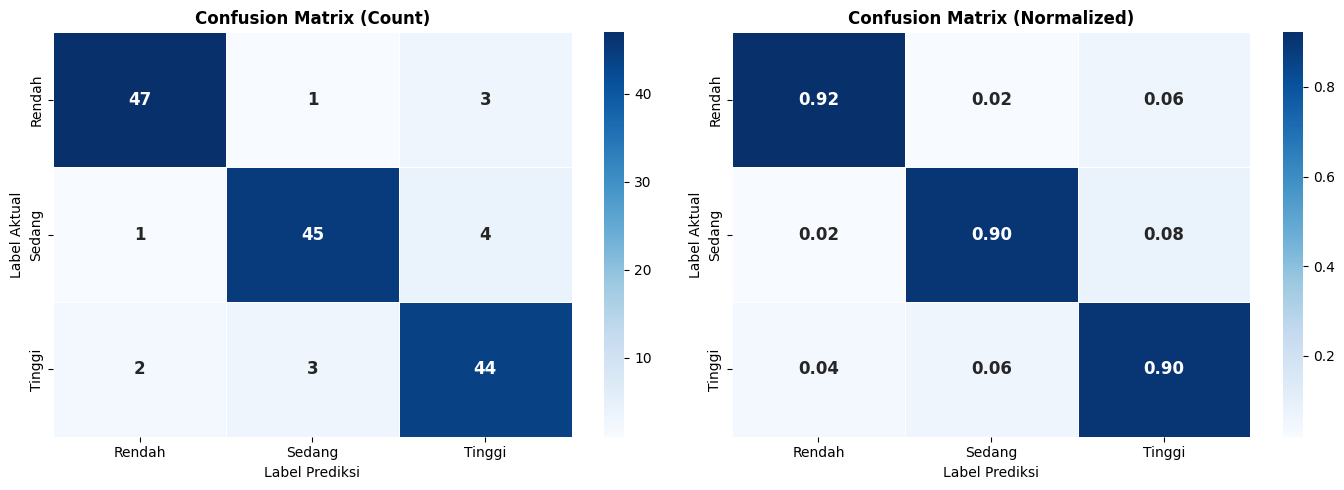

In [20]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ["d", ".2f"],
    ["Confusion Matrix (Count)", "Confusion Matrix (Normalized)"]
):
    sns.heatmap(data, annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap="Blues", ax=ax, linewidths=0.5,
                annot_kws={"size": 12, "weight": "bold"})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Label Aktual", fontsize=10)
    ax.set_xlabel("Label Prediksi", fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


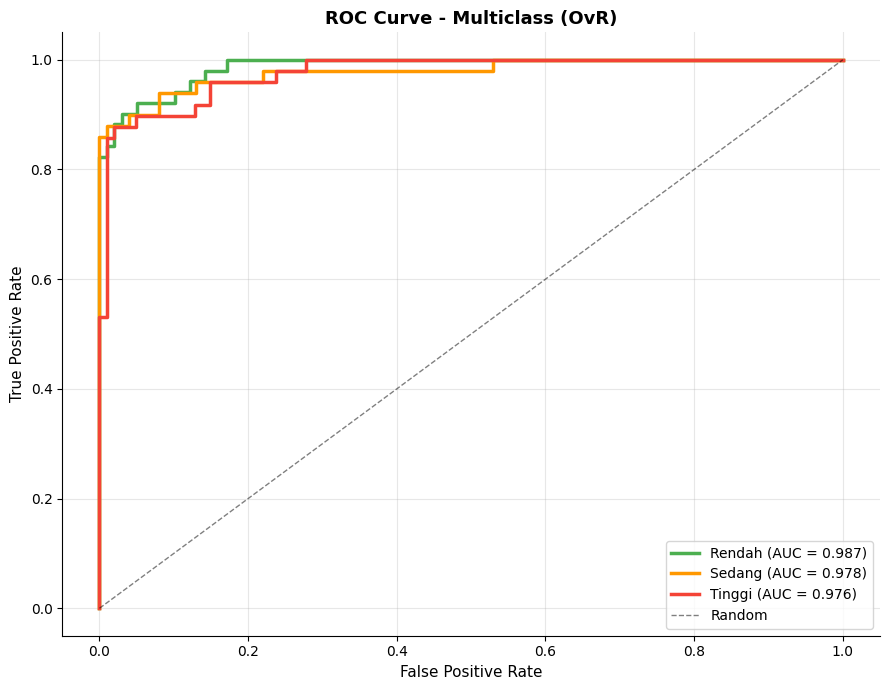

Macro-average ROC AUC : 0.9804


In [21]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_colors = ["#4CAF50", "#FF9800", "#F44336"]

plt.figure(figsize=(9, 7))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    auc_val      = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, color=color, lw=2.5, label="{} (AUC = {:.3f})".format(cls, auc_val))

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curve - Multiclass (OvR)", fontsize=13, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_pred_prob, average="macro")
print("Macro-average ROC AUC :", round(macro_auc, 4))


---
## Step 15 - Simpan Model dan Artefak

In [23]:
KERAS_PATH  = "../models/stress_mlp_final.keras"
H5_PATH     = "../models/stress_mlp_final.h5"
SCALER_PATH = "../models/scaler_params.json"

kept_models[0].save(KERAS_PATH)
print("Model utama disimpan (.keras) :", KERAS_PATH)

kept_models[0].save(H5_PATH)
print("Model utama disimpan (.h5)    :", H5_PATH)

scaler_params = {
    "mean_"   : scaler.mean_.tolist(),
    "scale_"  : scaler.scale_.tolist(),
    "features": FEATURE_COLS,
    "n_models": len(kept_models),
}
with open(SCALER_PATH, "w") as f:
    json.dump(scaler_params, f, indent=2)
print("Scaler params disimpan        :", SCALER_PATH)

kept_indices   = [i for i, keep in enumerate(mask) if keep]
ensemble_paths = ["../models/ensemble_model_{}.keras".format(i) for i in kept_indices]

meta = {
    "ensemble_paths"  : ensemble_paths,
    "ensemble_weights": softmax_weights.tolist(),
    "temperature"     : float(best_temp),
    "features"        : FEATURE_COLS,
    "class_names"     : CLASS_NAMES,
    "n_models"        : len(kept_models),
    "scaler_path"     : SCALER_PATH,
    "min_val_acc"     : MIN_VAL_ACC,
}
with open("../models/ensemble_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Ensemble meta disimpan        : ../models/ensemble_meta.json")
print("Temperature tersimpan         : {:.2f}".format(best_temp))

for path in [KERAS_PATH, H5_PATH, SCALER_PATH, "../models/ensemble_meta.json"]:
    size = os.path.getsize(path)
    print("OK |", path, "|", size, "bytes")


Model utama disimpan (.keras) : stress_mlp_final.keras
Model utama disimpan (.h5)    : stress_mlp_final.h5
Scaler params disimpan        : scaler_params.json
Ensemble meta disimpan        : ensemble_meta.json
OK | stress_mlp_final.keras | 1499743 bytes
OK | stress_mlp_final.h5 | 1498528 bytes
OK | scaler_params.json | 2319 bytes
OK | ensemble_meta.json | 1462 bytes


---
## Step 16 - Verifikasi Load Model

In [24]:
with open("ensemble_meta.json") as f:
    meta = json.load(f)

loaded_ensemble = [
    keras.models.load_model(p, custom_objects=CUSTOM_OBJ)
    for p in meta["ensemble_paths"]
]
loaded_weights = np.array(meta["ensemble_weights"])

print("Model ensemble di-load :", len(loaded_ensemble), "model")
print("Bobot                  :", [round(w, 4) for w in loaded_weights])

sample        = X_test_sc[:5]
probs_orig    = np.average([m.predict(sample, verbose=0) for m in kept_models],
                            axis=0, weights=softmax_weights)
probs_loaded  = np.average([m.predict(sample, verbose=0) for m in loaded_ensemble],
                            axis=0, weights=loaded_weights)
max_diff      = float(np.max(np.abs(probs_orig - probs_loaded)))
print("Maksimum perbedaan probabilitas:", round(max_diff, 10))
print("Prediksi konsisten:", np.allclose(probs_orig, probs_loaded, atol=1e-5))


Model ensemble di-load : 8 model
Bobot                  : [np.float64(0.1159), np.float64(0.1159), np.float64(0.1031), np.float64(0.1159), np.float64(0.1467), np.float64(0.165), np.float64(0.165), np.float64(0.0724)]
Maksimum perbedaan probabilitas: 0.0
Prediksi konsisten: True


---
## Step 17 - Ringkasan Akhir

In [25]:
final_acc = accuracy_score(y_test, y_pred)
final_f1  = f1_score(y_test, y_pred, average="macro")
final_auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2]), y_pred_prob, average="macro")
final_mae = mean_absolute_error(y_test, y_pred)
avg_conf  = float(np.mean(np.max(y_pred_prob, axis=1)))
best_vals = [max(h["val_accuracy"]) for h in ensemble_history]

print("=" * 62)
print("  RINGKASAN MODEL WEIGHTED ENSEMBLE")
print("=" * 62)
print("  Dataset          : final_clean_dataset.csv")
print("  Jumlah sampel    :", len(df_fe))
print("  Fitur            :", len(FEATURE_COLS))
print()
print("  Strategi         : StratifiedKFold {}-Fold + Weighted Ensemble".format(N_FOLDS))
print("  Model dipakai    : {}/{} (val_acc >= {})".format(
    len(kept_models), len(ensemble_models), MIN_VAL_ACC))
print("  Pembobotan       : Softmax berdasarkan val_accuracy")
print("  Arsitektur       : MLP 256-256-128-64 + Residual")
print("  Loss             : CategoricalCE + Label Smoothing 0.05")
print("  Optimizer        : AdamW + Warmup Cosine Decay")
print()
print("  Test Accuracy    : {:.4f} ({:.2f}%)".format(final_acc, final_acc * 100))
print("  Avg Confidence   : {:.4f} ({:.2f}%)".format(avg_conf, avg_conf * 100))
print("  Macro F1-Score   : {:.4f}".format(final_f1))
print("  Macro ROC AUC    : {:.4f}".format(final_auc))
print("  MAE              : {:.4f} ({:.2f}% dari range)".format(final_mae, final_mae / 2 * 100))
print()
target_hit = "TERCAPAI" if final_acc >= 0.90 else "BELUM TERCAPAI"
print("  Target 90%       :", target_hit)
print("=" * 62)


  RINGKASAN MODEL WEIGHTED ENSEMBLE
  Dataset          : final_clean_dataset.csv
  Jumlah sampel    : 1000
  Fitur            : 31

  Strategi         : StratifiedKFold 10-Fold + Weighted Ensemble
  Model dipakai    : 8/10 (val_acc >= 0.87)
  Pembobotan       : Softmax berdasarkan val_accuracy
  Arsitektur       : MLP 256-256-128-64 + Residual
  Loss             : CategoricalCE + Label Smoothing 0.05
  Optimizer        : AdamW + Warmup Cosine Decay

  Test Accuracy    : 0.9067 (90.67%)
  Avg Confidence   : 0.8803 (88.03%)
  Macro F1-Score   : 0.9066
  Macro ROC AUC    : 0.9804
  MAE              : 0.1267 (6.33% dari range)

  Target 90%       : TERCAPAI


---
## Step 18 - Inference Pipeline

In [26]:
with open("../models/ensemble_meta.json") as f:
    meta = json.load(f)

inf_ensemble = [
    keras.models.load_model(p, custom_objects=CUSTOM_OBJ)
    for p in meta["ensemble_paths"]
]
inf_weights     = np.array(meta["ensemble_weights"])
inf_temperature = float(meta.get("temperature", 1.0))

with open(meta["scaler_path"]) as f:
    sc_params = json.load(f)

inf_mean  = np.array(sc_params["mean_"])
inf_scale = np.array(sc_params["scale_"])
inf_feats = sc_params["features"]

CLASS_ADVICE = {
    0: "Pola digital dan psikologis Anda terbilang sehat. Pertahankan kebiasaan positif ini.",
    1: "Terdapat indikasi stres sedang. Pertimbangkan mengurangi screen time dan memperbanyak istirahat.",
    2: "Indikasi stres tinggi terdeteksi. Evaluasi jadwal digital, tingkatkan kualitas tidur, dan cari dukungan.",
}

def add_engineered_features(data: dict) -> dict:
    d = data.copy()
    d["screen_to_sleep_ratio"]    = d["Daily_Screen_Time_Hours"] / (d["sleep_quality"] + 1)
    d["social_vs_productivity"]   = d["Social_Media_Usage_Hours"] / (d["Productivity_App_Usage_Hours"] + 0.01)
    d["mental_digital_composite"] = d["mental_risk_score"] * d["digital_overload_score"]
    d["anxiety_depression_sum"]   = d["anxiety_level"] + d["depression"]
    d["support_pressure_diff"]    = d["social_support"] - d["peer_pressure"]
    d["passive_screen_ratio"]     = (
        d["Social_Media_Usage_Hours"] + d["Gaming_App_Usage_Hours"]
    ) / (d["Total_App_Usage_Hours"] + 0.01)
    d["academic_stress_index"]    = d["study_load"] * d["future_career_concerns"]
    d["wellbeing_deficit"]        = (
        d["anxiety_level"] + d["depression"] + d["peer_pressure"]
    ) - (d["social_support"] * 2 + d["sleep_quality"])
    return d


def apply_temperature(probs, temperature):
    logits = np.log(np.clip(probs, 1e-7, 1.0))
    scaled = logits / temperature
    exp_s  = np.exp(scaled - scaled.max())
    return exp_s / exp_s.sum()


def predict_stress(data: dict, show_detail: bool = True) -> dict:
    enriched = add_engineered_features(data)
    x        = np.array([enriched[f] for f in inf_feats], dtype=np.float32)
    x_scaled = (x - inf_mean) / inf_scale

    probs_all  = [m.predict(x_scaled.reshape(1, -1), verbose=0)[0] for m in inf_ensemble]
    probs_raw  = np.average(probs_all, axis=0, weights=inf_weights)
    probs      = apply_temperature(probs_raw, inf_temperature)
    cls        = int(np.argmax(probs))

    result = {
        "stress_class" : CLASS_NAMES[cls],
        "stress_index" : cls,
        "confidence"   : float(probs[cls]),
        "prob_rendah"  : float(probs[0]),
        "prob_sedang"  : float(probs[1]),
        "prob_tinggi"  : float(probs[2]),
        "rekomendasi"  : CLASS_ADVICE[cls],
    }

    if show_detail:
        bar_max = 35
        print("=" * 60)
        print("  HASIL ANALISIS STRES")
        print("=" * 60)
        print("  Tingkat Stres  :", result["stress_class"].upper())
        print("  Confidence     : {:.1f}%".format(result["confidence"] * 100))
        print()
        print("  Distribusi Probabilitas:")
        for lbl, key in zip(CLASS_NAMES, ["prob_rendah", "prob_sedang", "prob_tinggi"]):
            pct = result[key] * 100
            bar = "#" * int(result[key] * bar_max)
            print("  {:8s}: [{:<{}}] {:5.1f}%".format(lbl, bar, bar_max, pct))
        print()
        print("  Rekomendasi:")
        print(" ", result["rekomendasi"])
        print("=" * 60)

    return result


print("Inference pipeline siap (temperature={:.2f}).".format(inf_temperature))


Inference pipeline (weighted ensemble) siap.


---
## Step 19 - Tes Inferensi

In [27]:
profil_rendah = {
    "anxiety_level": 4, "self_esteem": 25, "mental_health_history": 0,
    "depression": 3, "headache": 1, "sleep_quality": 4,
    "academic_performance": 4, "study_load": 2, "future_career_concerns": 1,
    "social_support": 3, "peer_pressure": 1, "bullying": 0, "Age": 20,
    "Total_App_Usage_Hours": 3.5, "Daily_Screen_Time_Hours": 4.2,
    "Number_of_Apps_Used": 8, "Social_Media_Usage_Hours": 0.8,
    "Productivity_App_Usage_Hours": 2.1, "Gaming_App_Usage_Hours": 0.5,
    "digital_overload_score": 5.2, "productivity_balance_score": 0.6,
    "study_stress_ratio": 0.5, "mental_risk_score": 8,
}
print("--- Profil: Mahasiswa Sehat ---")
r1 = predict_stress(profil_rendah)


--- Profil: Mahasiswa Sehat ---
  HASIL ANALISIS STRES (Weighted Ensemble 8 Model)
  Tingkat Stres  : RENDAH
  Confidence     : 98.6%

  Distribusi Probabilitas:
  Rendah  : [################################## ]  98.6%
  Sedang  : [                                   ]   0.8%
  Tinggi  : [                                   ]   0.6%

  Rekomendasi:
  Pola digital dan psikologis Anda terbilang sehat. Pertahankan kebiasaan positif ini.


In [28]:
profil_sedang = {
    "anxiety_level": 11, "self_esteem": 17, "mental_health_history": 0,
    "depression": 12, "headache": 3, "sleep_quality": 3,
    "academic_performance": 2, "study_load": 3, "future_career_concerns": 3,
    "social_support": 2, "peer_pressure": 3, "bullying": 2, "Age": 21,
    "Total_App_Usage_Hours": 6.5, "Daily_Screen_Time_Hours": 7.8,
    "Number_of_Apps_Used": 17, "Social_Media_Usage_Hours": 2.4,
    "Productivity_App_Usage_Hours": 2.5, "Gaming_App_Usage_Hours": 2.4,
    "digital_overload_score": 12.7, "productivity_balance_score": 0.38,
    "study_stress_ratio": 1.0, "mental_risk_score": 29,
}
print("--- Profil: Mahasiswa Stres Sedang ---")
r2 = predict_stress(profil_sedang)


--- Profil: Mahasiswa Stres Sedang ---
  HASIL ANALISIS STRES (Weighted Ensemble 8 Model)
  Tingkat Stres  : SEDANG
  Confidence     : 84.5%

  Distribusi Probabilitas:
  Rendah  : [#                                  ]   4.0%
  Sedang  : [#############################      ]  84.5%
  Tinggi  : [####                               ]  11.5%

  Rekomendasi:
  Terdapat indikasi stres sedang. Pertimbangkan mengurangi screen time dan memperbanyak istirahat.


In [29]:
profil_tinggi = {
    "anxiety_level": 19, "self_esteem": 6, "mental_health_history": 1,
    "depression": 22, "headache": 5, "sleep_quality": 1,
    "academic_performance": 1, "study_load": 5, "future_career_concerns": 5,
    "social_support": 1, "peer_pressure": 5, "bullying": 4, "Age": 23,
    "Total_App_Usage_Hours": 10.8, "Daily_Screen_Time_Hours": 12.5,
    "Number_of_Apps_Used": 26, "Social_Media_Usage_Hours": 4.8,
    "Productivity_App_Usage_Hours": 0.4, "Gaming_App_Usage_Hours": 4.2,
    "digital_overload_score": 21.5, "productivity_balance_score": 0.04,
    "study_stress_ratio": 4.8, "mental_risk_score": 52,
}
print("--- Profil: Mahasiswa Stres Tinggi ---")
r3 = predict_stress(profil_tinggi)


--- Profil: Mahasiswa Stres Tinggi ---
  HASIL ANALISIS STRES (Weighted Ensemble 8 Model)
  Tingkat Stres  : TINGGI
  Confidence     : 93.7%

  Distribusi Probabilitas:
  Rendah  : [#                                  ]   3.8%
  Sedang  : [                                   ]   2.5%
  Tinggi  : [################################   ]  93.7%

  Rekomendasi:
  Indikasi stres tinggi terdeteksi. Evaluasi jadwal digital, tingkatkan kualitas tidur, dan cari dukungan.


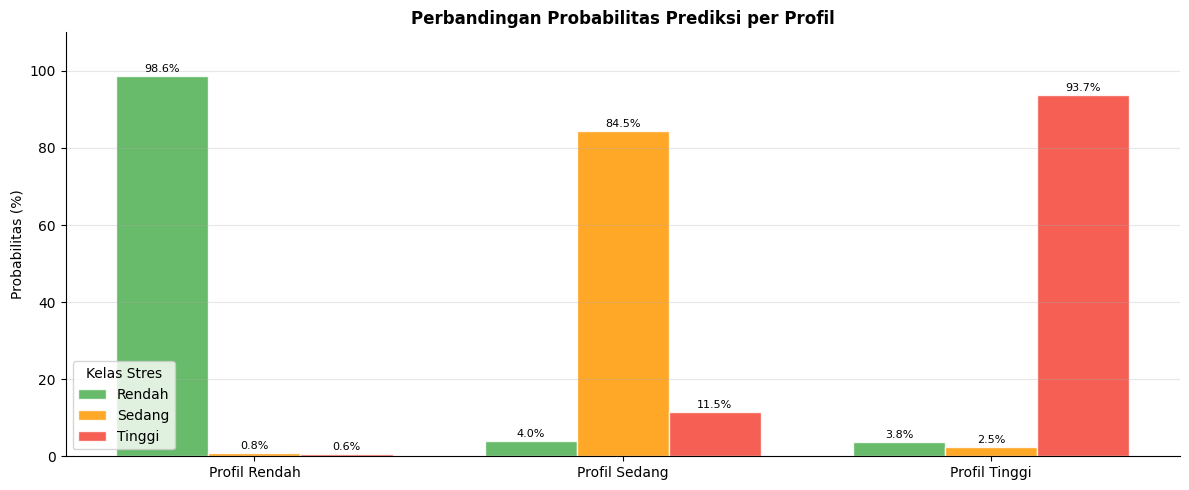

In [30]:
results = [r1, r2, r3]
labels  = ["Profil Rendah", "Profil Sedang", "Profil Tinggi"]

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(3)
width   = 0.25
colors  = ["#4CAF50", "#FF9800", "#F44336"]

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    key  = ["prob_rendah", "prob_sedang", "prob_tinggi"][i]
    vals = [r[key] * 100 for r in results]
    bars = ax.bar(x + i * width, vals, width, label=cls, color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                "{:.1f}%".format(val), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Probabilitas (%)")
ax.set_title("Perbandingan Probabilitas Prediksi per Profil", fontsize=12, fontweight="bold")
ax.legend(title="Kelas Stres")
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis="y")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("inference_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 20 - Batch Inference dari Test Set

In [31]:
probs_batch = np.average(
    [m.predict(X_test_sc, verbose=0) for m in kept_models],
    axis=0, weights=softmax_weights
)
preds_all = np.argmax(probs_batch, axis=1)
conf_all  = np.max(probs_batch, axis=1)

results_df = pd.DataFrame({
    "actual"    : [CLASS_NAMES[i] for i in y_test],
    "predicted" : [CLASS_NAMES[i] for i in preds_all],
    "confidence": conf_all.round(4),
    "correct"   : y_test == preds_all,
})

print("=== Ringkasan Batch Inference (Weighted Ensemble) ===")
print("Total sampel    :", len(results_df))
print("Benar           :", results_df["correct"].sum())
print("Salah           :", (~results_df["correct"]).sum())
print("Accuracy        : {:.2f}%".format(results_df["correct"].mean() * 100))
print("Avg Confidence  : {:.4f} ({:.2f}%)".format(conf_all.mean(), conf_all.mean() * 100))
print()
print("Confidence per kelas:")
for cls in CLASS_NAMES:
    subset = results_df[results_df["actual"] == cls]
    print("  {:8s}: avg={:.4f}  min={:.4f}  max={:.4f}".format(
        cls,
        subset["confidence"].mean(),
        subset["confidence"].min(),
        subset["confidence"].max()
    ))


=== Ringkasan Batch Inference (Weighted Ensemble) ===
Total sampel    : 150
Benar           : 136
Salah           : 14
Accuracy        : 90.67%
Avg Confidence  : 0.8803 (88.03%)

Confidence per kelas:
  Rendah  : avg=0.9035  min=0.3714  max=0.9919
  Sedang  : avg=0.8170  min=0.3996  max=0.9755
  Tinggi  : avg=0.9209  min=0.4184  max=0.9913


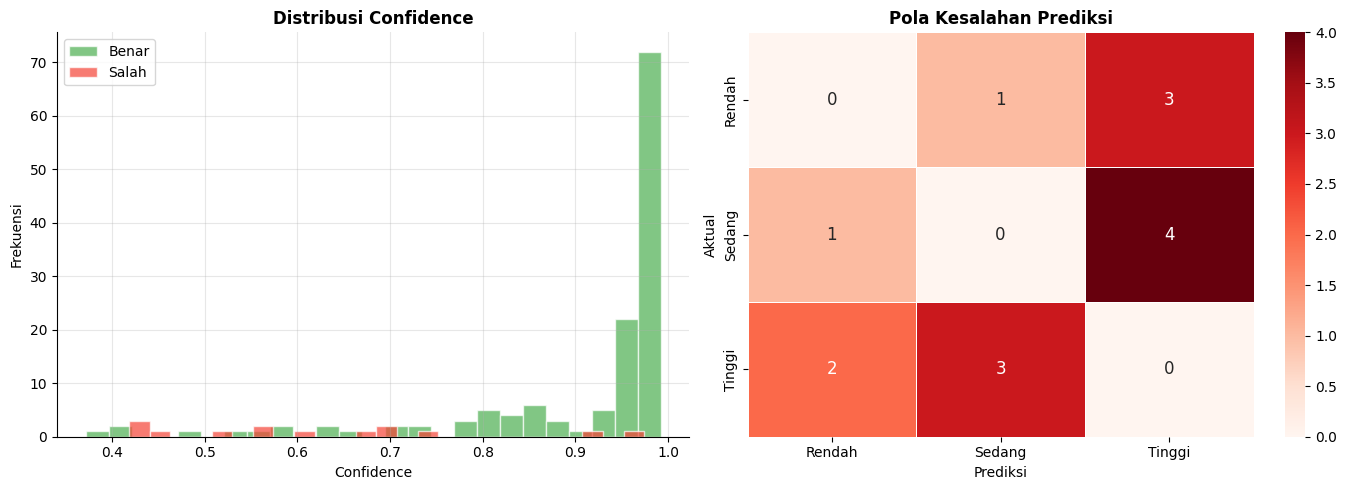

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(conf_all[y_test == preds_all], bins=25, color="#4CAF50",
             alpha=0.7, label="Benar", edgecolor="white")
axes[0].hist(conf_all[y_test != preds_all], bins=25, color="#F44336",
             alpha=0.7, label="Salah", edgecolor="white")
axes[0].set_title("Distribusi Confidence", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
sns.despine(ax=axes[0])

wrong_df = results_df[~results_df["correct"]]
if len(wrong_df) > 0:
    error_matrix = pd.crosstab(wrong_df["actual"], wrong_df["predicted"])
    sns.heatmap(error_matrix, annot=True, fmt="d", cmap="Reds",
                ax=axes[1], linewidths=0.5, annot_kws={"size": 12})
    axes[1].set_title("Pola Kesalahan Prediksi", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Aktual")
    axes[1].set_xlabel("Prediksi")
else:
    axes[1].text(0.5, 0.5, "Tidak ada kesalahan!", ha="center", va="center", fontsize=14)
    axes[1].set_title("Pola Kesalahan Prediksi", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("confidence_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
